1. Load data

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/dataset.csv')

df.head()

,Make,Model,Body,Mileage_km,Price,Year,Country,Condition,Fuel_Type,Fuel_Consumption_l,...,Cylinders,Seats,Doors,Color,Upholstery,Full_Service_History,Non_Smoker_Vehicle,Previous_Owners,Seller,Image_url
0,Abarth,595,Compact,98000,16900,2020.0,IT,Used,Gasoline,6.7,...,4.0,4.0,3.0,White,Full leather,False,False,NaN,Dealer,https://prod.pictures.autoscout24.net/listing-...
1,Abarth,595,Sedan,91500,12500,2017.0,IT,Used,Gasoline,6.0,...,4.0,4.0,3.0,Grey,Full leather,False,True,4.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
2,Abarth,595,Compact,40000,17990,2015.0,IT,Used,Gasoline,6.5,...,4.0,4.0,3.0,Bronze,Full leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
3,Abarth,500,Compact,133000,9300,2008.0,IT,Used,Gasoline,6.5,...,4.0,4.0,3.0,Black,Cloth,True,True,2.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
4,Abarth,595,Compact,61019,14990,2021.0,BE,Used,Gasoline,NaN,...,4.0,4.0,3.0,Yellow,Part leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...


2. Basic info

In [8]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 40494 entries, 0 to 40493
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Make                  40494 non-null  str    
 1   Model                 40273 non-null  str    
 2   Body                  40493 non-null  str    
 3   Mileage_km            40494 non-null  int64  
 4   Price                 40494 non-null  int64  
 5   Year                  38799 non-null  float64
 6   Country               37902 non-null  str    
 7   Condition             40494 non-null  str    
 8   Fuel_Type             40465 non-null  str    
 9   Fuel_Consumption_l    12773 non-null  float64
 10  Drivetrain            31860 non-null  str    
 11  Gearbox               40014 non-null  str    
 12  Gears                 25115 non-null  float64
 13  Power_hp              40494 non-null  int64  
 14  Engine_Size_cc        34564 non-null  float64
 15  Cylinders             30332 no

,Mileage_km,Price,Year,Fuel_Consumption_l,Gears,Power_hp,Engine_Size_cc,Cylinders,Seats,Doors,Previous_Owners
count,4.049400e+04,4.049400e+04,38799.000000,12773.000000,25115.000000,40494.000000,34564.000000,30332.000000,38697.000000,39517.000000,22271.000000
mean,7.723058e+04,5.662527e+04,2017.423877,6.727151,5.899024,231.339976,2275.084597,4.713339,4.633667,4.250879,1.406313
std,3.216313e+05,1.820272e+05,9.141150,3.544475,2.012859,179.923677,1540.972728,2.201816,1.652199,1.113654,1.027425
min,0.000000e+00,1.000000e+00,1922.000000,0.100000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000
25%,1.700000e+04,1.368350e+04,2015.000000,4.700000,5.000000,116.000000,1353.000000,4.000000,5.000000,4.000000,1.000000
50%,5.599500e+04,2.219950e+04,2020.000000,5.600000,6.000000,158.000000,1598.000000,4.000000,5.000000,5.000000,1.000000
75%,1.059982e+05,3.600000e+04,2023.000000,7.200000,7.000000,280.000000,2494.000000,4.000000,5.000000,5.000000,2.000000
max,1.677722e+07,9.999999e+06,2026.000000,55.000000,69.000000,3399.000000,67500.000000,50.000000,255.000000,25.000000,94.000000


3. Distributions of core columns

<Axes: xlabel='Make'>

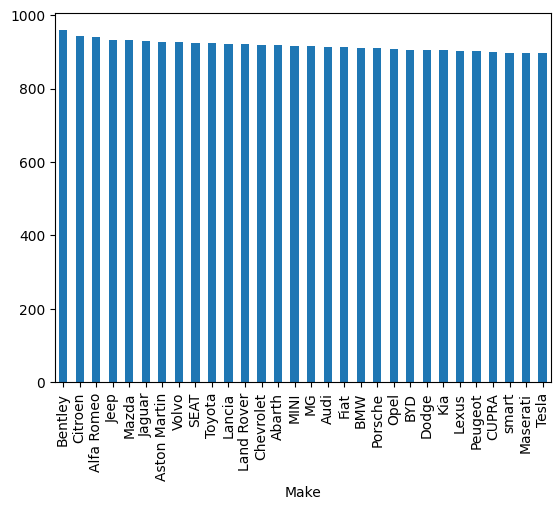

In [30]:
df['Make'].value_counts().head(30).plot(kind='bar')



<Axes: >

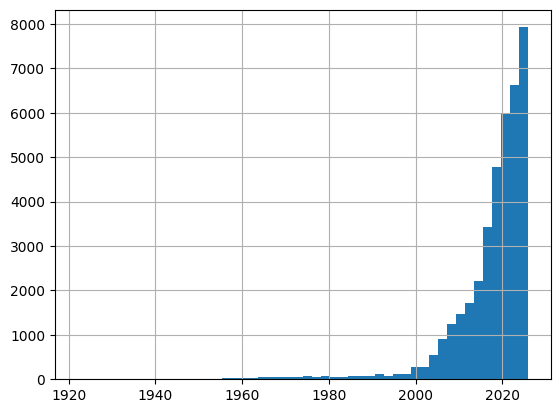

In [25]:

df['Year'].hist(bins=50)

<Axes: >

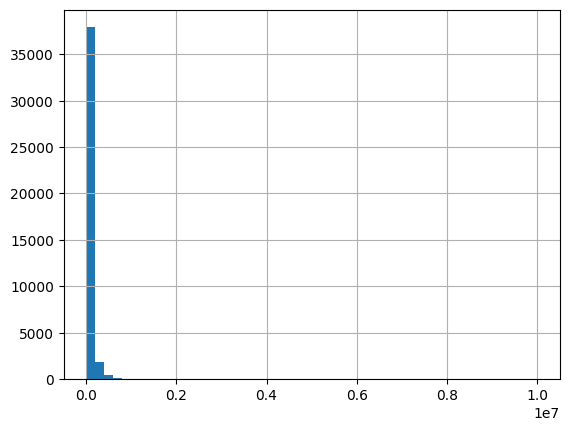

In [28]:

df['Price'].hist(bins=50)


<Axes: >

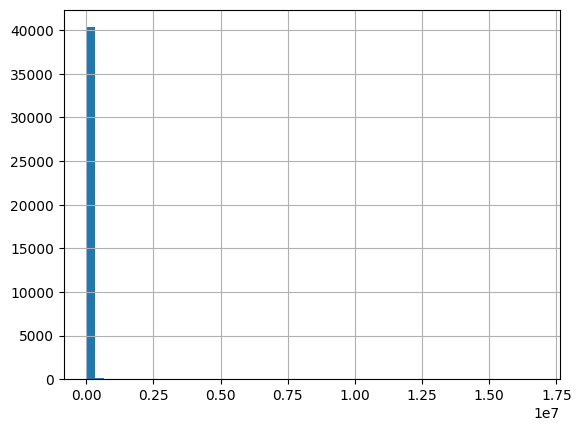

In [29]:
df['Mileage_km'].hist(bins=50)

4. Data quality issues

In [15]:
# Missing values
df[['Make', 'Model', 'Year', 'Mileage_km', 'Price']].isnull().sum()


Make             0
Model          221
Year          1695
Mileage_km       0
Price            0
dtype: int64

In [16]:
# Duplicates
df.duplicated().sum()

np.int64(0)

In [17]:
# Year ako float problém
df['Year'].dtype


dtype('float64')

In [18]:
# Year ako float problém
df['Year'].dtype


dtype('float64')

In [ ]:
# Outliers v cene
df['Price'].quantile([0.01, 0.05, 0.5, 0.95, 0.99])

0.01      1750.0
0.05      4490.0
0.50     22199.5
0.95    244900.0
0.99    541450.0
Name: Price, dtype: float64

5. Country and price analysis

In [19]:
# Distribúcia krajín
df['Country'].value_counts()

Country
DE    15494
IT     9769
NL     4179
BE     3789
ES     1857
FR     1363
AT     1338
LU      113
Name: count, dtype: int64

In [20]:
# Mediánová cena podľa krajiny
df.groupby('Country')['Price'].median().sort_values(ascending=False)

Country
FR    68900.0
LU    38860.0
AT    25910.5
DE    24470.0
ES    23955.0
BE    23950.0
IT    18900.0
NL    16450.0
Name: Price, dtype: float64

<Axes: xlabel='Country'>

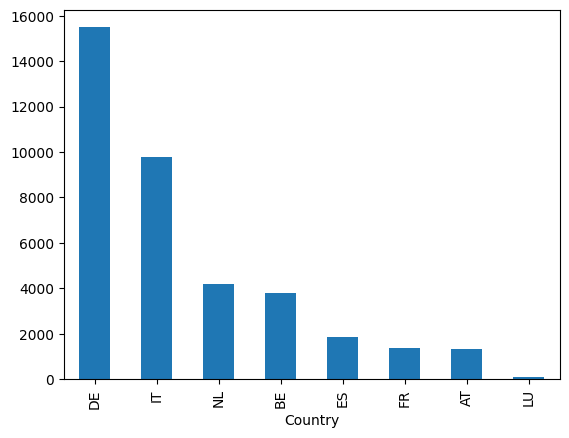

In [21]:
# Počet áut podľa krajiny (top 10)
df['Country'].value_counts().head(10).plot(kind='bar')

6. Decisions for cleaning

Based on data exploration, the cleaning pipeline:

1. **Drops rows with NaN in core columns** (Make, Model, Year, 
   Mileage_km, Price)

2. **Drops technical artifacts**: 14 rows where Mileage_km equals 
   16777215 — this is 2^24-1, a technical overflow value from 
   the scraping pipeline, not real mileage

3. **Filters outliers**:
   - Year between 1950 and 2026
   - Price between 100 and 300 000 EUR (drops cars with 
     unrealistic prices like 1 EUR for a new car)
   - Mileage_km between 0 and 500 000 km

4. **Casts Year and Mileage_km from float to int** after dropping NaN

5. **Drops duplicate rows** (defensive — 0 duplicates found currently)


In [ ]:
7. Dataset characteristics

- 40 495 rows, 25 columns
- EU listings from autoscout24
- All prices in EUR
- **Quota-balanced by brand (~1000 entries per make), so brand 
  distribution does not represent real EU market share
- Mean price (~56k EUR) is unreliable due to extreme outliers; 
  median (~22k EUR) used throughout the project